# Bloc 03 - Conversion rate challenge

## 01 - EDA

## Import libraries

In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import Image, display
from plotly.subplots import make_subplots

## Description du dataset

In [3]:
data = pd.read_csv('../data/conversion_data_train.csv')
print('Set with labels (our train+test) :', data.shape)

Set with labels (our train+test) : (284580, 6)


In [4]:
data.head(10)

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0
5,US,29,0,Seo,7,0
6,US,30,1,Direct,4,0
7,UK,38,1,Ads,2,0
8,UK,26,1,Seo,4,0
9,UK,31,0,Seo,5,0


In [5]:
rows, cols = data.shape
print("Number of rows :", rows)
print("Number of columns  :", cols)

print()
print("Basics statistics :")
display(data.describe(include="all"))

print()
missing_values = data.isna().sum() / rows
print("Percentage of missing values:", missing_values)

print()
print("age", data["age"].value_counts())

print()
print("country", data["country"].value_counts())

print()
print("source", data["source"].value_counts())

print()
print("total_pages_visited", data["total_pages_visited"].value_counts())

print()
print("converted", data["converted"].value_counts())

Number of rows : 284580
Number of columns  : 6

Basics statistics :


,country,age,new_user,source,total_pages_visited,converted
count,284580,284580.000000,284580.000000,284580,284580.000000,284580.000000
unique,4,NaN,NaN,3,NaN,NaN
top,US,NaN,NaN,Seo,NaN,NaN
freq,160124,NaN,NaN,139477,NaN,NaN
mean,NaN,30.564203,0.685452,NaN,4.873252,0.032258
std,NaN,8.266789,0.464336,NaN,3.341995,0.176685
min,NaN,17.000000,0.000000,NaN,1.000000,0.000000
25%,NaN,24.000000,0.000000,NaN,2.000000,0.000000
50%,NaN,30.000000,1.000000,NaN,4.000000,0.000000
75%,NaN,36.000000,1.000000,NaN,7.000000,0.000000



Percentage of missing values: country                0.0
age                    0.0
new_user               0.0
source                 0.0
total_pages_visited    0.0
converted              0.0
dtype: float64

age age
28     12972
30     12956
29     12710
27     12668
26     12525
31     12327
25     12157
32     12111
24     11647
33     11392
23     11097
34     10911
22     10471
35     10352
21      9870
36      9668
20      9131
37      8773
19      8452
38      8067
18      7662
39      7343
17      6825
40      6451
41      5783
42      5029
43      4423
44      3808
45      3249
46      2693
47      2255
48      1898
49      1467
50      1213
51       990
52       835
53       571
54       459
55       352
56       251
57       211
58       147
59       115
60        86
61        63
62        50
63        29
64        26
65        14
66         9
67         5
68         2
70         2
111        1
72         1
69         1
73         1
79         1
123        1
77         1
Nam

In [6]:
def show_images(fig, filename):
    fig.write_image(filename)
    display(Image(filename))

## Suppression des valeurs aberrantes

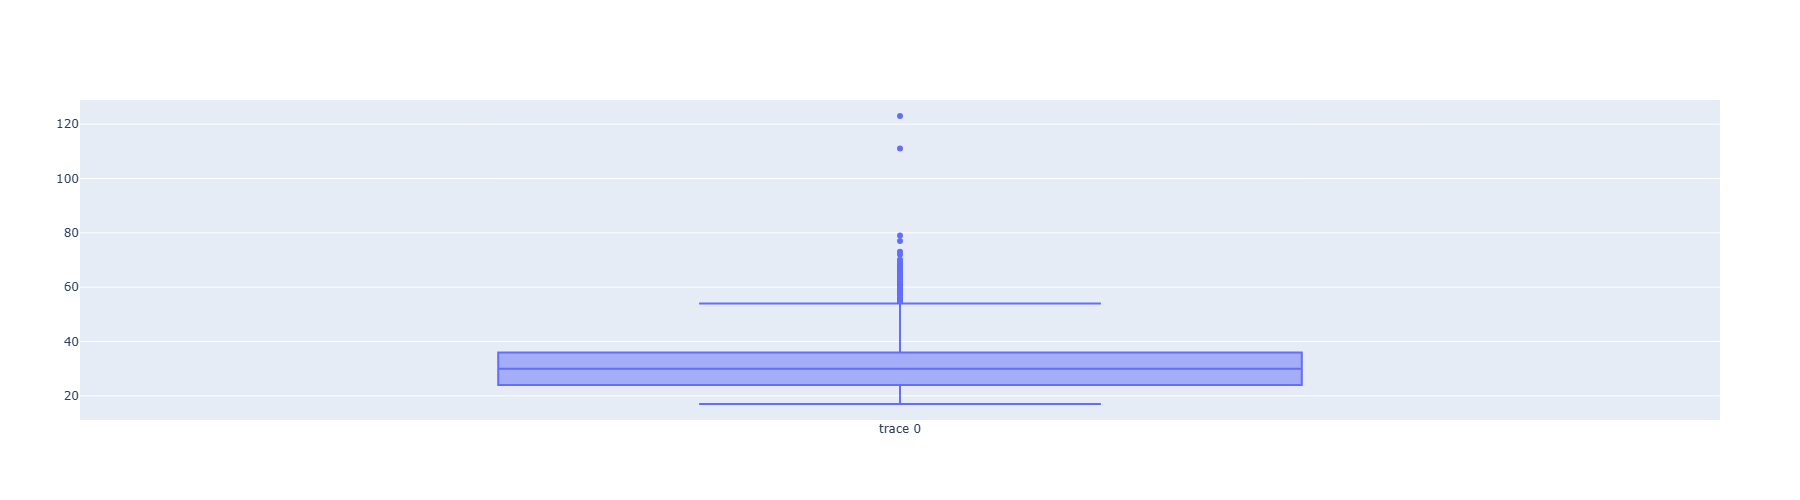

       country  age  new_user  source  total_pages_visited  converted
55          US   62         1     Seo                    4          0
296      China   58         1     Ads                    6          0
731      China   57         1     Seo                   11          0
965         US   56         1     Seo                    2          0
1014        US   61         1     Seo                    7          0
...        ...  ...       ...     ...                  ...        ...
283843      US   62         1  Direct                    4          0
284059      UK   62         1     Seo                    4          0
284483   China   61         0     Seo                    7          0
284493      US   60         1     Ads                    1          0
284548      US   64         0     Seo                    4          0

[1017 rows x 6 columns]


In [7]:
# age
age_data = data["age"]

age_mean = age_data.mean()
age_std = age_data.std()

age_outliers = data[
    (age_data < age_mean - 3 * age_std) |
    (age_data > age_mean + 3 * age_std)
]

age_outliers_fig = go.Figure()
age_outliers_fig.add_trace(go.Box(y=data["age"]))
age_outliers_fig.update_layout(width=1800, height=500)
age_outliers_fig.show()

show_images(age_outliers_fig, "../images/age_outliers_fig.png")

print(age_outliers)

In [8]:
# suppression des valeurs aberrantes de la variable age
data.drop(index=age_outliers.index.to_list(), inplace=True)

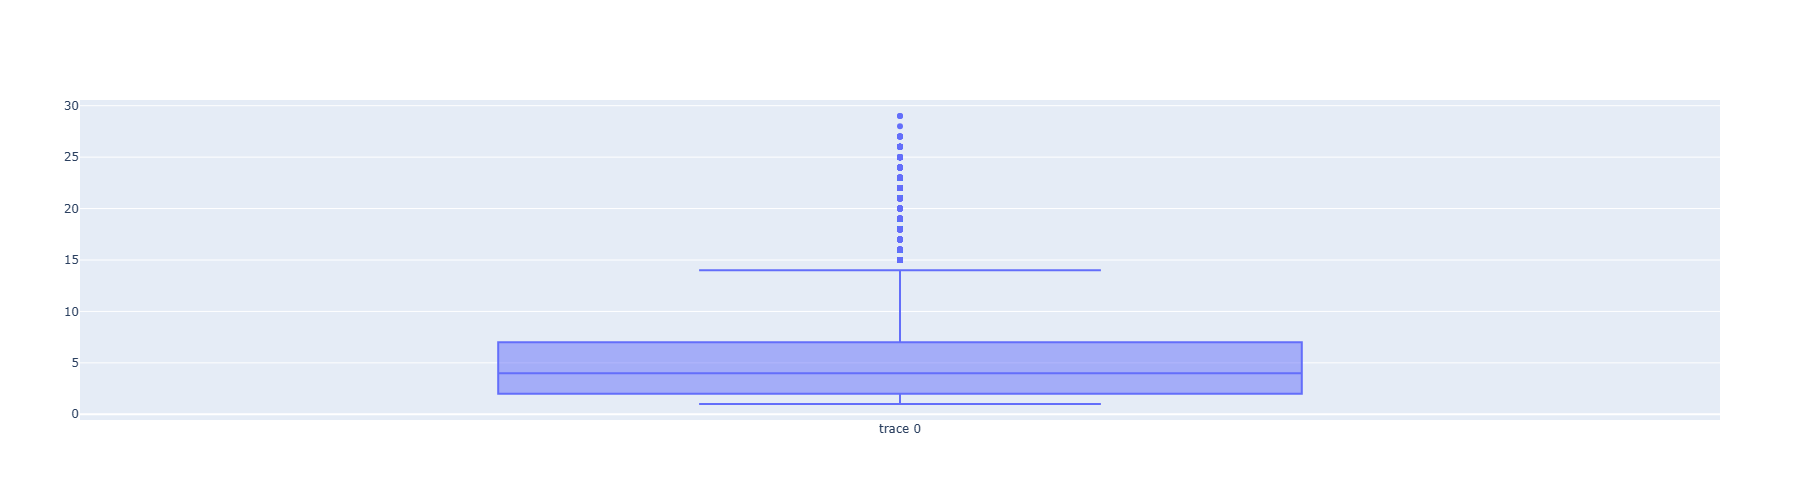

       country  age  new_user  source  total_pages_visited  converted
42          UK   27         0     Seo                   16          1
127         US   32         1     Seo                   19          1
200         US   41         0     Seo                   20          1
207         UK   26         1     Ads                   15          1
234         UK   20         0     Ads                   21          1
...        ...  ...       ...     ...                  ...        ...
284330      US   39         0     Seo                   18          1
284354      UK   22         1     Ads                   22          1
284434      US   22         0  Direct                   23          1
284464      US   23         0     Seo                   15          1
284486      US   32         0     Seo                   21          1

[5114 rows x 6 columns]


In [9]:
# total_pages_visited
total_pages_visited_data = data["total_pages_visited"]

total_pages_visited_mean = total_pages_visited_data.mean()
total_pages_visited_std = total_pages_visited_data.std()

total_pages_visited_outliers = data[
    (total_pages_visited_data < total_pages_visited_mean - 3 * total_pages_visited_std) |
    (total_pages_visited_data > total_pages_visited_mean + 3 * total_pages_visited_std)
]

total_pages_visited_outliers_fig = go.Figure()
total_pages_visited_outliers_fig.add_trace(go.Box(y=data["total_pages_visited"]))
total_pages_visited_outliers_fig.update_layout(width=1800, height=500)
total_pages_visited_outliers_fig.show()

show_images(total_pages_visited_outliers_fig, "../images/total_pages_visited_outliers_fig.png")

print(total_pages_visited_outliers)

In [10]:
# suppression des valeurs aberrantes de la variable total_pages_visited
data.drop(index=total_pages_visited_outliers.index.to_list(), inplace=True)

In [11]:
data.shape

(278449, 6)

In [12]:
data.to_csv("../data/conversion_data_train_cleaned.csv")

## EDA

In [13]:
age_counts = (
    data.groupby(["age", "country"])
      .size()
      .reset_index(name="count")
      .sort_values(["age", "country"])
)
age_counts

,age,country,count
0,17,China,1635
1,17,Germany,275
2,17,UK,1033
3,17,US,3632
4,18,China,1828
...,...,...,...
151,54,US,254
152,55,China,77
153,55,Germany,16
154,55,UK,53


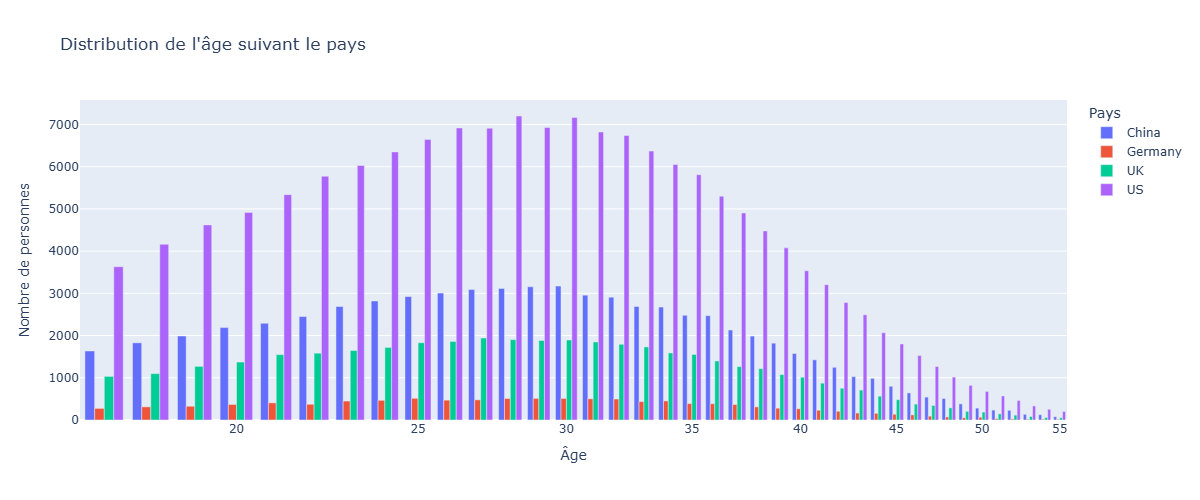

In [14]:
age_fig = px.bar(age_counts, 
    x="age", 
    y="count", 
    color="country",
    barmode="group",
    title="Distribution de l'âge suivant le pays",
    labels={
        "age": "Âge",
        "count": "Nombre de personnes",
        "country": "Pays"
    },
    width=1200,
    height=500,
    log_x=True,
    
)
age_fig.show()

show_images(age_fig, "../images/age_fig.png")

La nationalité la plus représentée est américaine.  
Le pic se situe vers 28-32 ans.  

L'Allemagne est peu représentée.  

Tous les pays ont un coeur de population autour de 25-35 ans.

In [15]:
countries = data["country"].unique()

converted_counts = (
    data.groupby(["converted", "country"])
      .size()
      .reset_index(name="count")
      .sort_values(["converted", "country"])
)
converted_counts

,converted,country,count
0,0,China,68647
1,0,Germany,10904
2,0,UK,41132
3,0,US,153173
4,1,China,54
5,1,Germany,360
6,1,UK,1176
7,1,US,3003


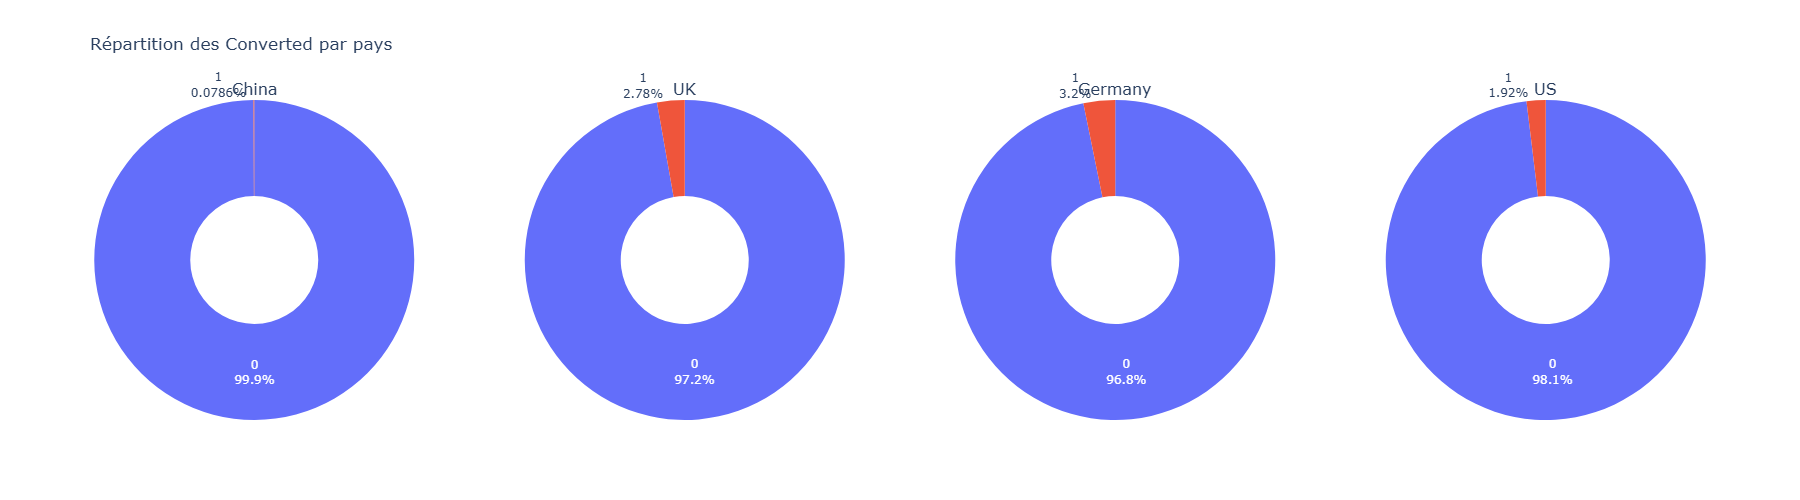

In [16]:
converted_fig = make_subplots(
    rows=1,
    cols=len(countries),
    specs=[[{"type": "domain"}] * len(countries)],
    subplot_titles=countries
)

for i, country in enumerate(countries, start=1):
    d = converted_counts[converted_counts["country"] == country]
    converted_fig.add_trace(
        go.Pie(
            labels=d["converted"].astype(str),
            values=d["count"],
            hole=0.4,
            textinfo="percent+label"
        ),
        row=1,
        col=i
    )

converted_fig.update_layout(
    title_text="Répartition des Converted par pays",
    showlegend=False,
    width=1800, 
    height=500
)
converted_fig.show()

show_images(converted_fig, "../images/converted_fig.png")


L'Allemagne présente le taux de conversion le plus élevé, mais c'est le marché qui a le plus faible volume de trafic.  
Quant à la Chine, le taux de conversion est extrêmement faible, malgré le fait qu'il s'agisse du 2e marché en terme de volume.

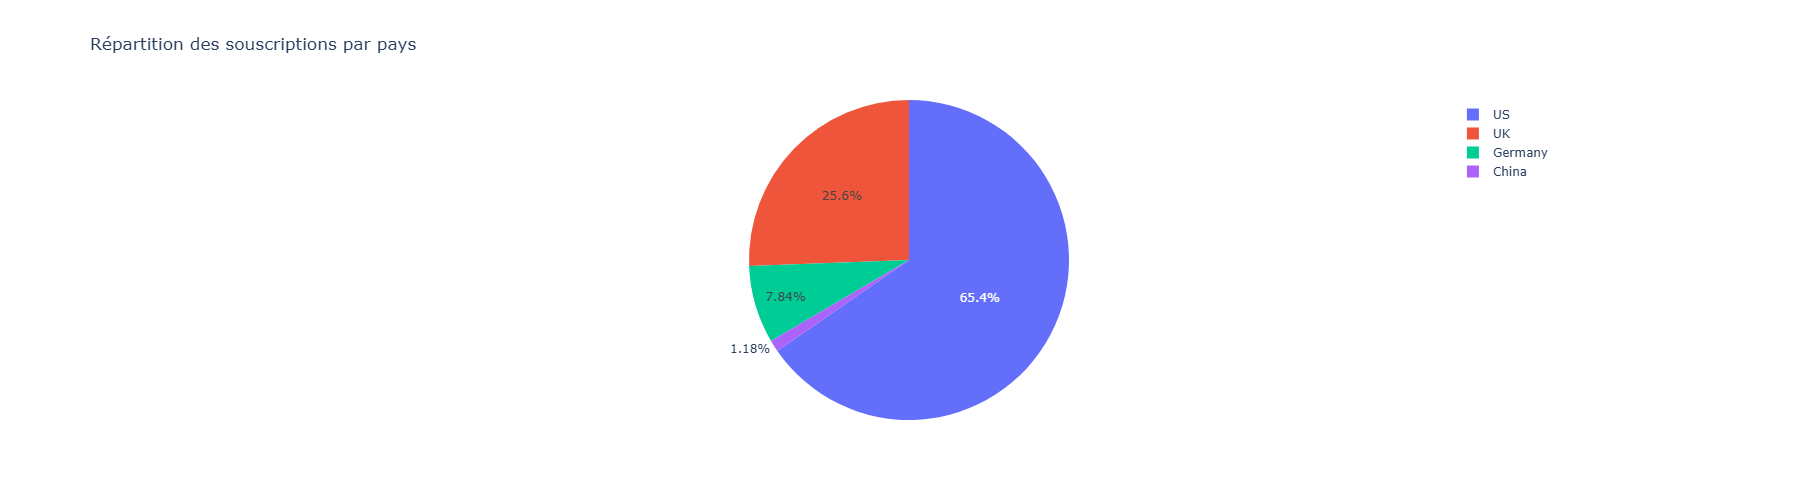

In [17]:
converted_counts_by_country = converted_counts[converted_counts["converted"] == 1]
converted_counts_by_country

converted_counts_by_country_fig = px.pie(
    values=converted_counts_by_country["count"],
    names=converted_counts_by_country["country"],
    title="Répartition des souscriptions par pays"
    )
converted_counts_by_country_fig.update_layout(width=1800, height=500)
converted_counts_by_country_fig.show()

show_images(converted_counts_by_country_fig, "../images/converted_counts_by_country_fig.png")


Pour les Converted, la majeur partie des souscriptions viennent des Etats-Unis.  
La Chine représente moins de 2% des souscriptions.

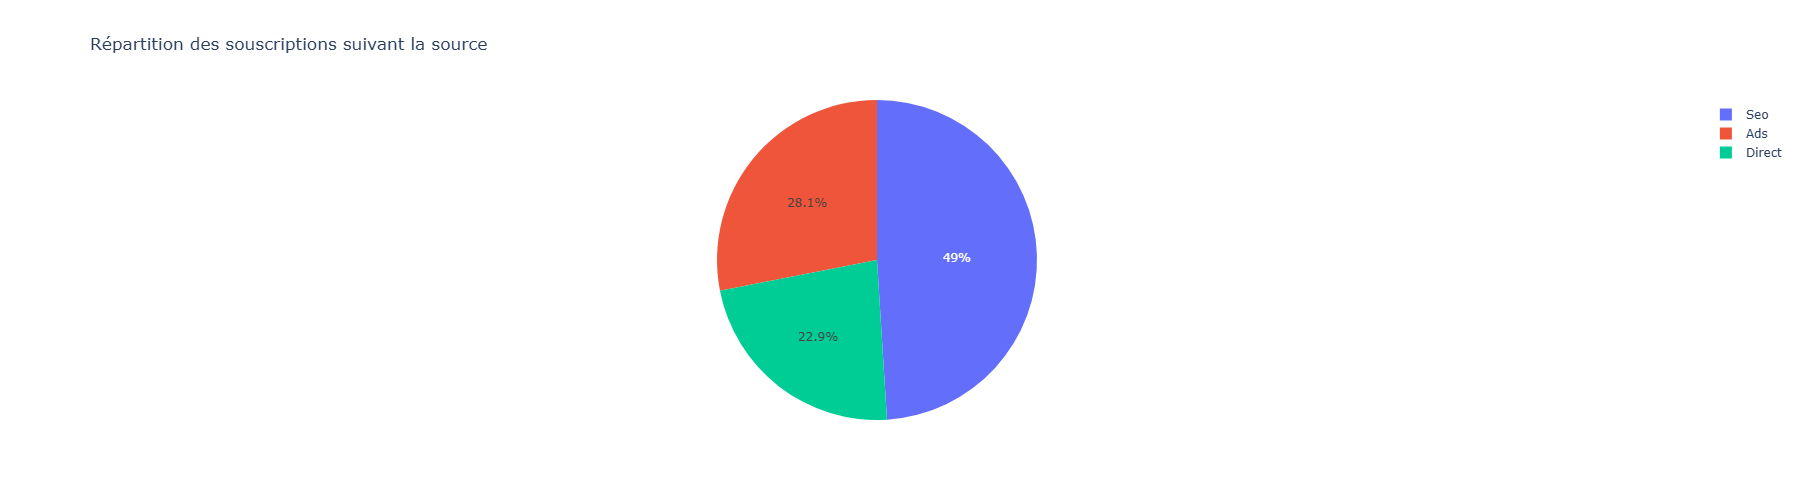

In [18]:
source_data = data["source"]
source_counts = source_data.value_counts()
source_fig = px.pie(
    values=source_counts, 
    names=source_counts.index,
    title="Répartition des souscriptions suivant la source"
)
source_fig.update_layout(width=1800, height=500)
source_fig.show()

show_images(source_fig, "../images/source_fig.png")

Le SEO est la source majoritaire.  
Le reste est partagé entre les Ads et l'accès direct.

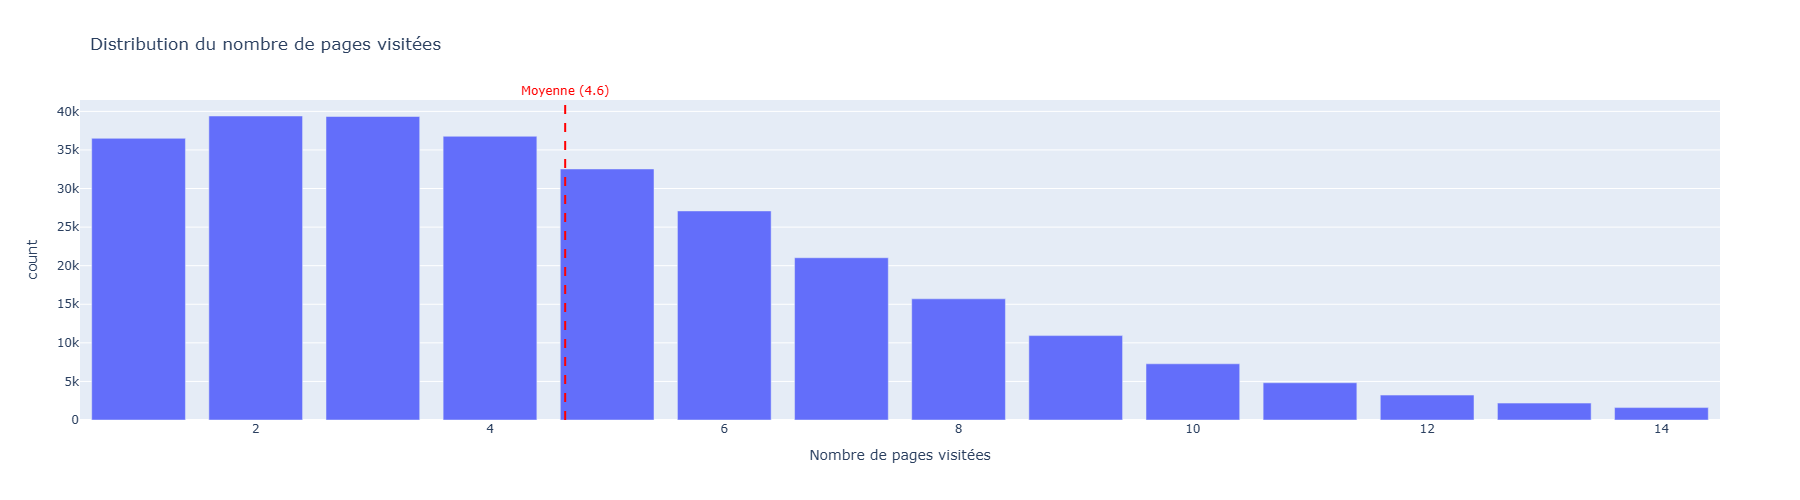

In [19]:
total_pages_visited_counts = (
    data.groupby(["total_pages_visited"])
      .size()
      .reset_index(name="count")
      .sort_values(["total_pages_visited"])
)

total_pages_visited_fig = px.bar(
    total_pages_visited_counts, 
    x="total_pages_visited", 
    y="count",
    title="Distribution du nombre de pages visitées",
    labels={"total_pages_visited": "Nombre de pages visitées"}
)

total_pages_visited_mean = data["total_pages_visited"].mean()

total_pages_visited_fig.add_vline(
    x=total_pages_visited_mean,
    line_dash='dash',
    annotation_position='top',
    line_color="red",
    annotation=dict(
        text=f'Moyenne ({total_pages_visited_mean.round(1)})',
        font=dict(color='red')
    )
)
total_pages_visited_fig.update_layout(width=1800, height=500)
total_pages_visited_fig.show()

show_images(total_pages_visited_fig, "../images/total_pages_visited_fig.png")

Chaque utilisateur consulte en moyenne 4.6 pages.

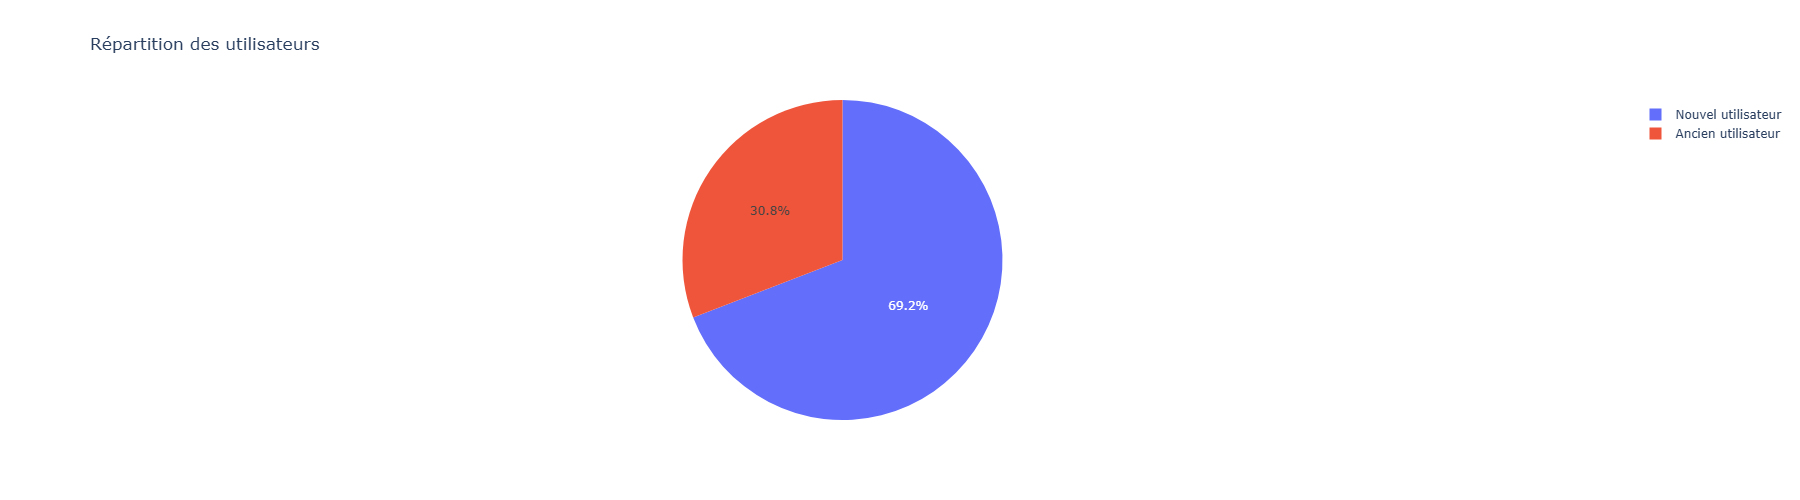

In [20]:
new_user_data = data["new_user"]
new_user_counts = new_user_data.value_counts()
new_user_counts.rename(index={0: "Ancien utilisateur", 1: "Nouvel utilisateur"}, inplace=True)

new_user_fig = px.pie(
    values=new_user_counts, 
    names=new_user_counts.index,
    title="Répartition des utilisateurs",
    labels={"new_user": "Type de produit"}
)
new_user_fig.update_layout(width=1800, height=500)
new_user_fig.show()

show_images(new_user_fig, "../images/new_user_fig.png")

30.8% des utilisateurs sont nouveaux.

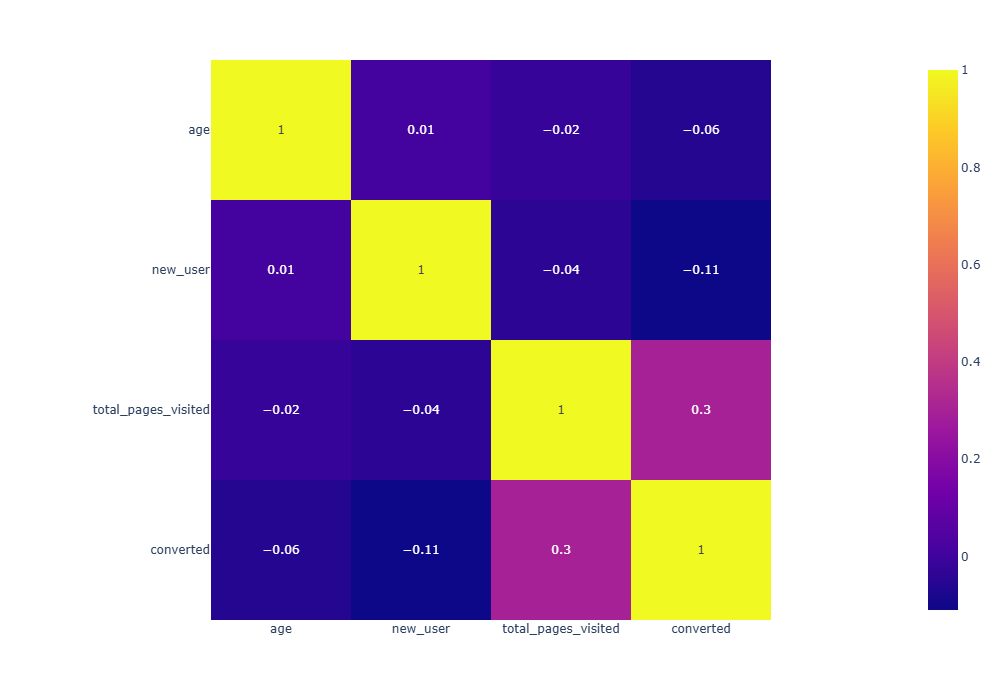

In [21]:
corr = data.select_dtypes(include="number").corr()
corr_fig = px.imshow(corr.round(2), text_auto=True, width=1000, height=700)
corr_fig.show()

show_images(corr_fig, "../images/corr_fig.png")

La relation la plus significative pour les conversions concerne la variable total_pages_visited, puis new_user.  

In [ ]:
converted_by_pages_visited = (
    data.groupby("total_pages_visited")["converted"]
        .mean()
        .reset_index()
)

converted_by_pages_visited_fig = px.line(converted_by_pages_visited, 
        x="total_pages_visited", 
        y="converted",
        title="Taux de conversion en fonction du nombre de pages visitées")

show_images(converted_by_pages_visited_fig, "../images/converted_by_pages_visited_fig.png")